In [8]:
import pandas as pd
import numpy as np
import itertools
import random
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [9]:
input_file = r"D:\Materi Kuliah S2\Teknik Integrasi Data\year-2026.merged.csv"
output_file = r"filtered.csv"

target_value = "Belanja Alat/Bahan untuk Kegiatan Kantor-Alat Tulis Kantor"

In [10]:
df = pd.read_csv(input_file)

filtered = df[df.iloc[:, 0] == target_value]

filtered.to_csv(output_file, index=False)

print("Selesai filtering!")
print("Total:", len(filtered))

Selesai filtering!
Total: 138534


In [11]:
INPUT_FILE = "filtered.csv"
OUTPUT_FILE = "label_jaccard_1000.csv"

SAMPLE_PER_GROUP = 20
MAX_PAIRS_PER_GROUP = 200
THRESHOLD = 0.8

TEXT_COL = "uraianPekerjaan"

SAVE_COLS = [
    "uraianPekerjaan",
    "spesifikasiPekerjaan",
    "jenisPengadaan"
]

In [12]:
def jaccard(a, b):
    a_set = set(str(a).lower().split())
    b_set = set(str(b).lower().split())

    if len(a_set | b_set) == 0:
        return 0.0

    return len(a_set & b_set) / len(a_set | b_set)

def exact_match(a, b):
    return 1.0 if str(a).lower() == str(b).lower() else 0.0

In [13]:
df = pd.read_csv(INPUT_FILE)

print("Total data:", len(df))

Total data: 138534


In [14]:
df["_group"] = (
    df["lembaga"].astype(str) + "||" +
    df["satker"].astype(str) + "||" +
    df["lokasi"].astype(str) + "||" +
    df["pemilihanDate"].astype(str)
)

groups = df.groupby("_group")

In [15]:
results = []

for g, df_group in groups:

    if len(df_group) < 2:
        continue

    df_group = df_group.reset_index(drop=True)

    df_sample = df_group.sample(
        n=min(SAMPLE_PER_GROUP, len(df_group)),
        random_state=42
    )

    idxs = df_sample.index.tolist()

    pairs = list(itertools.combinations(idxs, 2))

    if len(pairs) > MAX_PAIRS_PER_GROUP:
        pairs = random.sample(pairs, MAX_PAIRS_PER_GROUP)

    for i, j in pairs:

        a = df_group.loc[i]
        b = df_group.loc[j]

        score = jaccard(a[TEXT_COL], b[TEXT_COL])
        label = "Mirip" if score >= THRESHOLD else "Tidak Mirip"

        row = {
            "A_index": i,
            "B_index": j,
            "jaccard": score,
            "label": label
        }

        for col in SAVE_COLS:
            row[f"{col}_A"] = a[col]
            row[f"{col}_B"] = b[col]

        results.append(row)

In [16]:
df_out = pd.DataFrame(results)

print("Total pairs:", len(df_out))

df_out.to_csv(OUTPUT_FILE, index=False)

print("DONE:", OUTPUT_FILE)

Total pairs: 583589
DONE: label_jaccard_1000.csv


In [55]:
df = pd.read_csv(r"D:\Materi Kuliah S2\Teknik Integrasi Data\ETS-IntegrasiData\label_jaccard_1000.csv")

print("Sebelum balancing:")
print(df['label'].value_counts())

df_mirip = df[df['label'] == 'Mirip']
df_tidak = df[df['label'] == 'Tidak Mirip']

n = min(len(df_mirip), len(df_tidak))

df_mirip_sample = df_mirip.sample(n=n, random_state=42)
df_tidak_sample = df_tidak.sample(n=n, random_state=42)

df_balance = pd.concat([df_mirip_sample, df_tidak_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nSesudah balancing:")
print(df_balance['label'].value_counts())
print("Total:", len(df_balance))

df_balance.head()

Sebelum balancing:
label
Tidak Mirip    441551
Mirip          142038
Name: count, dtype: int64

Sesudah balancing:
label
Tidak Mirip    142038
Mirip          142038
Name: count, dtype: int64
Total: 284076


,A_index,B_index,jaccard,label,uraianPekerjaan_A,uraianPekerjaan_B,spesifikasiPekerjaan_A,spesifikasiPekerjaan_B,jenisPengadaan_A,jenisPengadaan_B
0,97714,96384,0.714286,Tidak Mirip,Amplop; Ballpoint- Staff; Buku Tulis; Buku Tul...,Ballpoint- Staff; Amplop; Map Folio;,; ; ; ; ; ; ; ; ; Biasa; ; ; ; ; Biasa; ; Bias...,; ; Bermotif;,Barang,Barang
1,34689,29716,0.000000,Tidak Mirip,Bolpoin;,Clip; Tinta Stampel Yamura; Box Arsip; Map gan...,hitam;,Clip No.3; Tinta Stampel; Box Arsip Besar; fol...,Barang,Barang
2,75108,66727,0.263158,Tidak Mirip,Map biasa; Fotocopy/penggandaan; Anak hekter; ...,Anak hekter; Pena; Binderclip; Binderclip; Bin...,"; hitam putih, folio; No. 10; 1/2 folio bergar...",No. 10; Balliner; No. 200; No. 155; No. 111; N...,Barang,Barang
3,6865,7879,1.000000,Mirip,Belanja Alat/Bahan untuk Kegiatan Kantor berup...,Belanja Alat/Bahan untuk Kegiatan Kantor berup...,Foto Copy Kertas HVS folio,"Foto Copy Kertas HVS folio , Stopmap Plastik ,...",Barang,Barang
4,44403,48086,1.000000,Mirip,Alat Tulis Kantor; Alat Tulis Kantor; Alat Tul...,Alat Tulis Kantor; Alat Tulis Kantor; Alat Tul...,Penjepit kertas; Stop Map Folio; Paper clips N...,Stop Map Folio; Penjepit kertas; Paper clips N...,Barang,Barang


In [56]:
X = []

for _, row in df_balance.iterrows():
    X.append([
        jaccard(row["uraianPekerjaan_A"], row["uraianPekerjaan_B"]),
        jaccard(row["spesifikasiPekerjaan_A"], row["spesifikasiPekerjaan_B"]),
        exact_match(row["jenisPengadaan_A"], row["jenisPengadaan_B"])
    ])

X = np.array(X)

y = (df_balance["label"] == "Mirip").astype(int)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (284076, 3)
Shape y: (284076,)


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 227260
Test: 56816


In [58]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

w = model.coef_[0]
print("Model trained")

Model trained


In [59]:
print("\n=== WEIGHT RAW ===")
print(f"Uraian        : {w[0]:.4f}")
print(f"Spesifikasi   : {w[1]:.4f}")
print(f"Jenis         : {w[2]:.4f}")


=== WEIGHT RAW ===
Uraian        : 43.9117
Spesifikasi   : 0.8900
Jenis         : 0.3369


In [60]:
totw = abs(w[0])+abs(w[1])+abs(w[2])
w_uraian  = w[0]/totw
w_spesifikasi  = w[1]/totw
w_jenis  = w[2]/totw

print("\n=== WEIGHT DALAM SKALA 1 ===")
print(f"Uraian weight      : {w_uraian :.4f}")
print(f"Spesifikasi weight : {w_spesifikasi :.4f}")
print(f"Jenis weight       : {w_jenis :.4f}")


=== WEIGHT DALAM SKALA 1 ===
Uraian weight      : 0.9728
Spesifikasi weight : 0.0197
Jenis weight       : 0.0075


In [39]:
df = pd.read_csv("filtered.csv")

print("Total data:", len(df))
df.head()

THRESHOLD = 0.8

Total data: 138534


In [40]:
df["_group"] = (
    df["lembaga"].astype(str) + "||" +
    df["satker"].astype(str) + "||" +
    df["lokasi"].astype(str) + "||" +
    df["pemilihanDate"].astype(str)
)

groups = df.groupby("_group")

In [41]:
results = []

for g, df_group in groups:

    if len(df_group) < 2:
        continue

    idxs = df_group.index.tolist()

    for i, j in itertools.combinations(idxs, 2):

        a = df.loc[i]
        b = df.loc[j]

        sim_uraian = jaccard(a["uraianPekerjaan"], b["uraianPekerjaan"])
        sim_spesifikasi = jaccard(a["spesifikasiPekerjaan"], b["spesifikasiPekerjaan"])
        sim_jenis = exact_match(a["jenisPengadaan"], b["jenisPengadaan"])

        score = (
            w_uraian * sim_uraian +
            w_spesifikasi * sim_spesifikasi +
            w_jenis * sim_jenis
        )

        label = "Mirip" if score >= THRESHOLD else "Tidak Mirip"

        row = {
            "A_index": i,
            "B_index": j,

            "sim_uraian": sim_uraian,
            "sim_spesifikasi": sim_spesifikasi,
            "sim_jenis": sim_jenis,
            "final_score": score,
            "label": label,
        }

        # simpan semua kolom A dan B
        for col in df.columns:
            if col != "_group":
                row[f"{col}_A"] = a[col]
                row[f"{col}_B"] = b[col]

        results.append(row)

In [42]:
df_out = pd.DataFrame(results)

print("DONE")
print("Total pairs:", len(df_out))

df_out.to_csv("hasil_similarity_weighted_full.csv", index=False)

print("Saved to: hasil_similarity_weighted_full.csv")

DONE
Total pairs: 979797
Saved to: hasil_similarity_weighted_full.csv


<Axes: xlabel='label'>

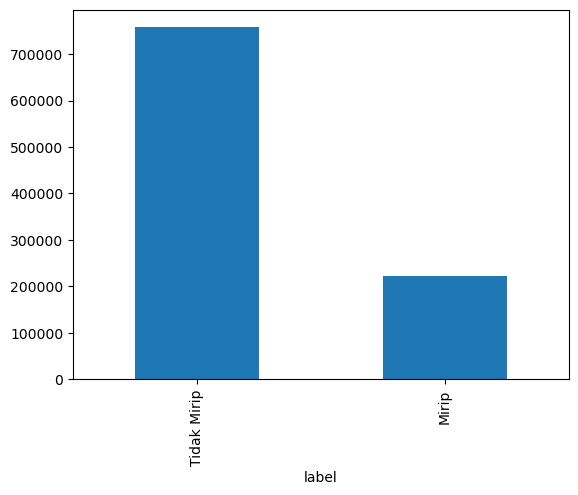

In [43]:
df_out["label"].value_counts().plot(kind="bar")

In [44]:
df = pd.read_csv("hasil_similarity_weighted_full.csv")

print("Total data:", len(df))

df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_25648\2389407889.py:1: DtypeWarning: Columns (43,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("hasil_similarity_weighted_full.csv")


Total data: 979797


,A_index,B_index,sim_uraian,sim_spesifikasi,sim_jenis,final_score,label,paket_A,paket_B,dalamNegeri_A,...,potensiPemborosan_A,potensiPemborosan_B,tags.isInappropriate_A,tags.isInappropriate_B,tags.inappropriateReason_A,tags.inappropriateReason_B,jumlahTagAktif_A,jumlahTagAktif_B,_source_part_A,_source_part_B
0,136149,136256,1.0,1.0,1.0,0.943742,Mirip,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,True,...,0.0,0.0,low,low,NaN,NaN,0,0,122,122
1,136149,136515,1.0,1.0,1.0,0.943742,Mirip,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,True,...,0.0,0.0,low,low,NaN,NaN,0,0,122,122
2,136149,136584,1.0,1.0,1.0,0.943742,Mirip,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,True,...,0.0,0.0,low,low,NaN,NaN,0,0,122,122
3,136149,136648,1.0,1.0,1.0,0.943742,Mirip,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,True,...,0.0,0.0,low,low,NaN,NaN,0,0,122,122
4,136149,136651,1.0,1.0,1.0,0.943742,Mirip,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,Belanja Alat/Bahan untuk Kegiatan Kantor-Alat ...,True,...,0.0,0.0,low,low,NaN,NaN,0,0,122,122


In [45]:
dfMirip = df[df["label"] == "Mirip"].copy()

print("Total Mirip:", len(dfMirip))

Total Mirip: 222033


In [46]:
dfMirip["pagu_A"] = pd.to_numeric(dfMirip["pagu_A"], errors="coerce")
dfMirip["pagu_B"] = pd.to_numeric(dfMirip["pagu_B"], errors="coerce")

dfMirip = dfMirip.dropna(subset=["pagu_A", "pagu_B"])

dfMirip["pagu_diff_pct"] = abs(
    dfMirip["pagu_A"] - dfMirip["pagu_B"]
) / dfMirip[["pagu_A", "pagu_B"]].max(axis=1)

anomali_pagu = dfMirip[dfMirip["pagu_diff_pct"] > 0.5]

print("Anomali Pagu:", len(anomali_pagu))

Anomali Pagu: 125797


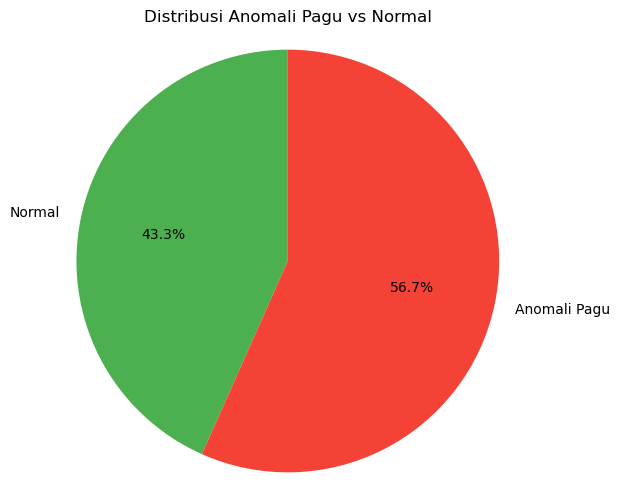

In [47]:
total = len(dfMirip)
anomali = len(anomali_pagu)
normal = total - anomali

labels = ["Normal", "Anomali Pagu"]
sizes = [normal, anomali]
colors = ["#4CAF50", "#F44336"]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Distribusi Anomali Pagu vs Normal")
plt.axis("equal")  # biar bulat sempurna
plt.show()

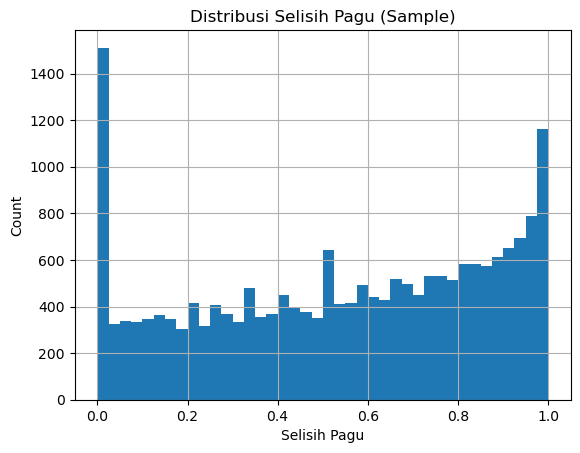

In [48]:
plt.figure()

dfMirip["pagu_diff_pct"] \
    .sample(min(20000, len(dfMirip))) \
    .hist(bins=40)

plt.title("Distribusi Selisih Pagu (Sample)")
plt.xlabel("Selisih Pagu")
plt.ylabel("Count")
plt.show()

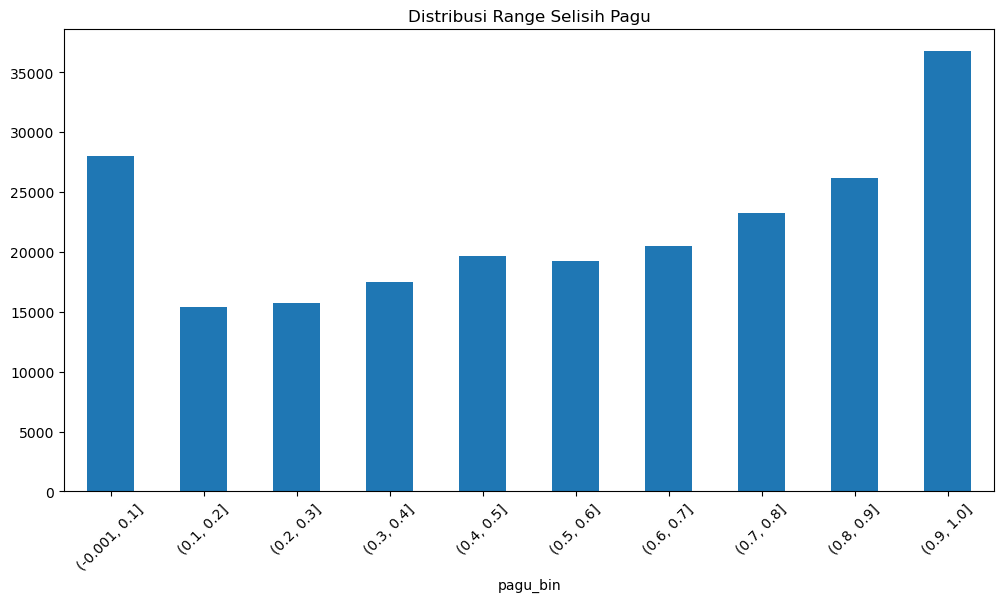

In [49]:
dfMirip["pagu_bin"] = pd.cut(dfMirip["pagu_diff_pct"], bins=10)

plt.figure(figsize=(12,6))
dfMirip["pagu_bin"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribusi Range Selisih Pagu")
plt.xticks(rotation=45)
plt.show()

In [50]:
anomali_pagu.to_csv("anomali_pagu.csv", index=False)

print("Saved: anomali_pagu.csv")

Saved: anomali_pagu.csv


In [51]:
anomali_metode = dfMirip[dfMirip["metode_A"] != dfMirip["metode_B"]]

print("Anomali Metode:", len(anomali_metode))

Anomali Metode: 8085


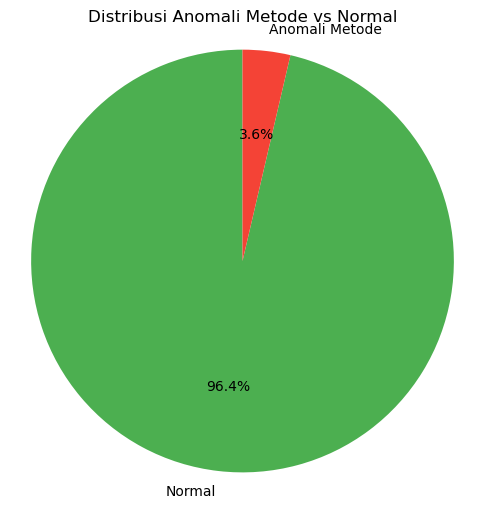

In [52]:
total = len(dfMirip)
anomali = len(anomali_metode)
normal = total - anomali

labels = ["Normal", "Anomali Metode"]
sizes = [normal, anomali]
colors = ["#4CAF50", "#F44336"]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Distribusi Anomali Metode vs Normal")
plt.axis("equal")  # biar bulat sempurna
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_25648\2206243172.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomali_metode["metode_pair"] = (


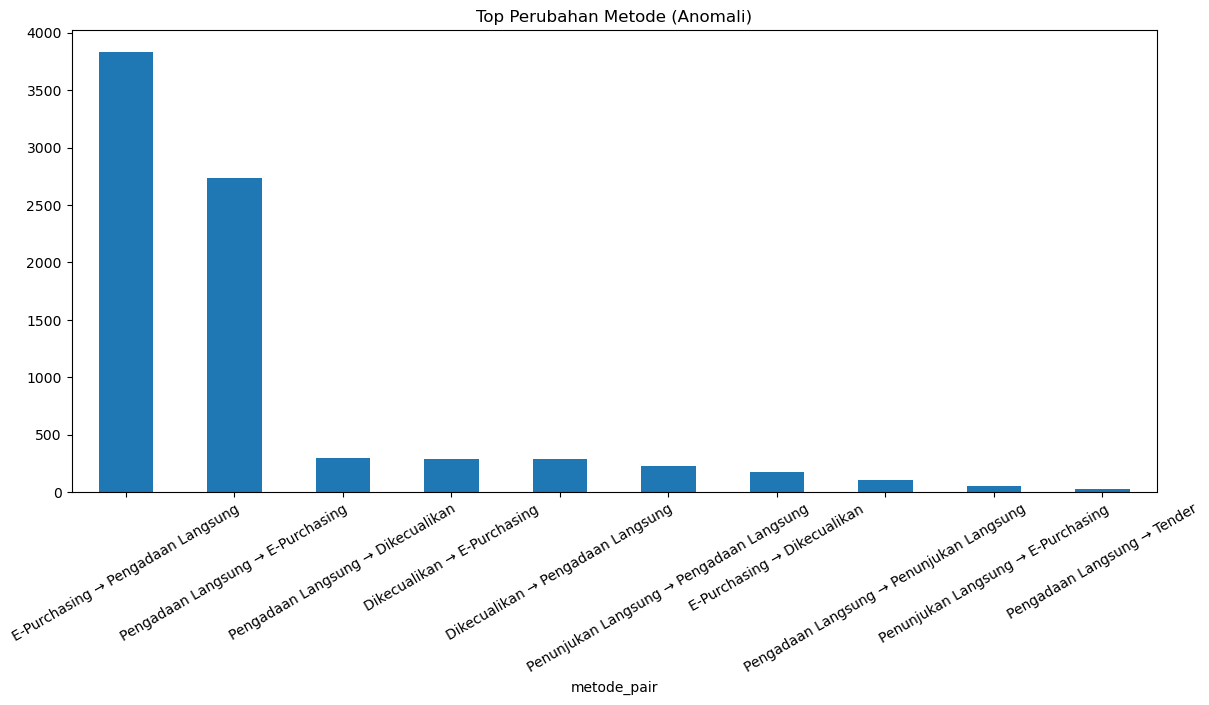

In [53]:
anomali_metode["metode_pair"] = (
    anomali_metode["metode_A"] + " → " + anomali_metode["metode_B"]
)

plt.figure(figsize=(14,6))
anomali_metode["metode_pair"] \
    .value_counts() \
    .head(10) \
    .plot(kind="bar")

plt.title("Top Perubahan Metode (Anomali)")
plt.xticks(rotation=30)
plt.show()

In [54]:
anomali_metode.to_csv("anomali_metode.csv", index=False)

print("Saved: anomali_metode.csv")

Saved: anomali_metode.csv
